In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor
import pandas as pd

# -------------------------
# COPY DATA
# -------------------------
X_enc = X.copy()

# -------------------------
# HANDLE MISSING
# -------------------------
X_enc = X_enc.fillna("missing")

# -------------------------
# ONE-HOT ENCODE CATEGORICALS
# -------------------------
X_enc = pd.get_dummies(X_enc)

# -------------------------
# SPLIT
# -------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)

# -------------------------
# MODEL
# -------------------------
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------
# PERMUTATION IMPORTANCE
# -------------------------
result = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_squared_error"
)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": result.importances_mean
}).sort_values("importance")

print("\n🔍 LOW IMPORTANCE FEATURES")
print(importance_df.head(20))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3192
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 216
[LightGBM] [Info] Start training from score 12.030658

🔍 LOW IMPORTANCE FEATURES
                  feature  importance
0                      Id   -0.000200
836  SaleCondition_Normal   -0.000193
678        Functional_Typ   -0.000171
21           TotRmsAbvGrd   -0.000156
814            Fence_GdWo   -0.000100
27          EnclosedPorch   -0.000084
270   Exterior2nd_VinylSd   -0.000060
274    MasVnrType_BrkFace   -0.000056
650          Heating_GasA   -0.000045
662      Electrical_FuseA   -0.000043
277        MasVnrArea_0.0   -0.000041
663      Electrical_FuseF   -0.000036
605          ExterQual_Ex   -0.000030
755    GarageYrBlt

C:\Users\rhysj\OneDrive\Desktop\SWE\Python\Kaggle & Python\House Prices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3192
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 216
[LightGBM] [Info] Start training from score 12.030658


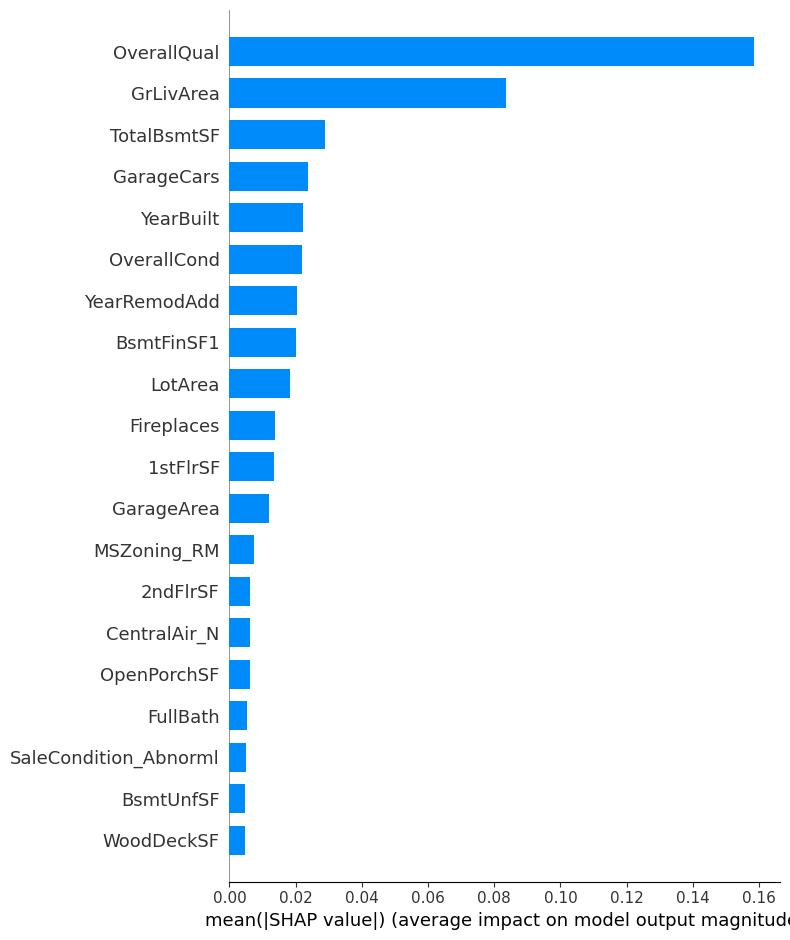

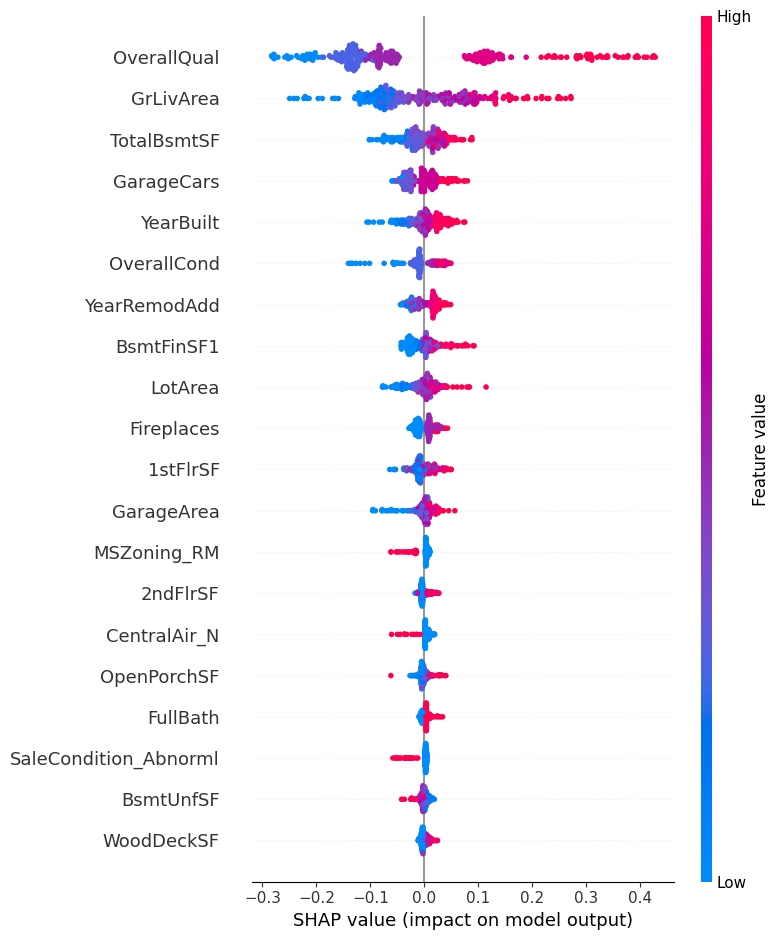

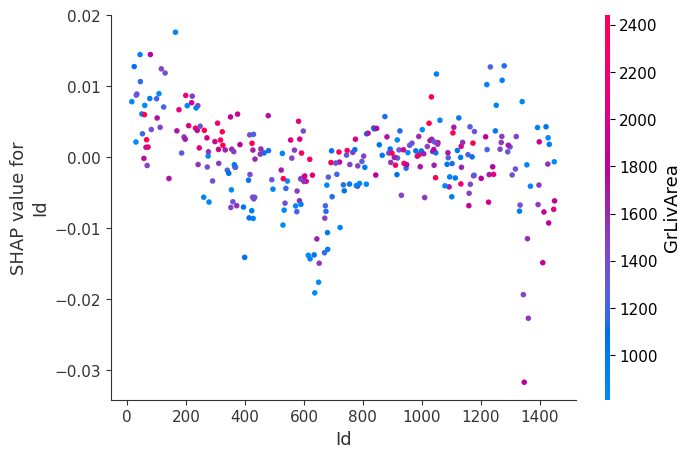

In [67]:
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# -------------------------
# PREP DATA (must be numeric!)
# -------------------------
X_enc = X.copy()
X_enc = X_enc.fillna("missing")
X_enc = pd.get_dummies(X_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)

# -------------------------
# TRAIN MODEL
# -------------------------
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------
# SHAP EXPLAINER
# -------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

# -------------------------
# GLOBAL FEATURE IMPORTANCE
# -------------------------
shap.summary_plot(shap_values, X_val, plot_type="bar")

# -------------------------
# FULL DISTRIBUTION VIEW
# -------------------------
shap.summary_plot(shap_values, X_val)

# -------------------------
# SINGLE FEATURE INSIGHT (optional)
# -------------------------
shap.dependence_plot(
    X_val.columns[0],  # change to feature you want
    shap_values,
    X_val
)

In [61]:
# Load dataset, only send in folder locaiton? or relative and have project in same spot?
train_file_path = r"house-prices-advanced-regression-techniques\train.csv"
test_file_path = r"house-prices-advanced-regression-techniques\test.csv"
sample_file_path =r"house-prices-advanced-regression-techniques\sample_submission.csv"

df = pd.read_csv(train_file_path)
evaluation = pd.read_csv(test_file_path)
sample_output = pd.read_csv(sample_file_path)

In [62]:
import numpy as np

# Features and target
X = df.drop('SalePrice', axis=1)
y = np.log1p(df["SalePrice"])
# Temp and Final_Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [63]:
# Handle missing values (quick + dirty baseline)
X_temp = X_temp.fillna(-999)

# One-hot encode categorical variables
X_temp = pd.get_dummies(X_temp)

# Train and Valuation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42
)

In [ ]:
# Cell 2: Train Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initialize and train model
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=1)
model.fit(X_train, y_train)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Split features and target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Split FIRST (prevents leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Handle missing values
X_train = X_train.fillna(-999)
X_val = X_val.fillna(-999)

# One-hot encoding (fit on train, apply to val)
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)

# Align columns (VERY important)
X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

# -----------------------------
# 7. Train
# -----------------------------
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# -----------------------------
# 8. Evaluate
# -----------------------------
preds = model.predict(X_val)

rmse = mean_squared_error(y_val, preds)
print("RMSE:", rmse)

In [ ]:
predictions = model.predict(evaluation)
submission = pd.DataFrame({
    'id': df["id"],
    'SalePrice': predictions
})
submission.head()

In [ ]:
submission.to_csv('submission.csv', index=False)

In [ ]:
# Cell: Compare submission with sample_submission.csv

import pandas as pd

# Load sample submission
sample = pd.read_csv('sample_submission.csv')

# Load your submission
submission = pd.read_csv('submission.csv')

# Quick checks
print("Columns in sample submission:", sample.columns.tolist())
print("Columns in your submission:", submission.columns.tolist())

# Check if column names and order match
columns_match = sample.columns.tolist() == submission.columns.tolist()
print("Columns match:", columns_match)

# Check number of rows
print("Number of rows in sample:", len(sample))
print("Number of rows in submission:", len(submission))

# Check if IDs match
ids_match = sample['id'].equals(submission['id'])
print("IDs match:", ids_match)

# Full equality check (True only if everything matches exactly)
submission_matches_sample = submission.equals(sample)
print("Submission matches sample exactly:", submission_matches_sample)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Predict on your held-out test set
preds = model.predict(X_test)

# If log transform used
preds = np.expm1(preds)
y_test_true = np.expm1(y_test)

rmse = mean_squared_error(y_test_true, preds)
print("FINAL HOLDOUT RMSE:", rmse)

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# Parameter space
param_dist = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2]
}

# Random search
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit on training data only
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score:", -search.best_score_)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# -----------------------
# XGBoost
# -----------------------
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)

# -----------------------
# LightGBM
# -----------------------
lgb = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_val)

# -----------------------
# CatBoost
# -----------------------
cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=0,
    random_seed=42
)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_val)

# -----------------------
# Ensemble (simple average)
# -----------------------
ensemble_pred = (xgb_pred + lgb_pred + cat_pred) / 3

# -----------------------
# Evaluate
# -----------------------
rmse = mean_squared_error(y_val, ensemble_pred)
print("Ensemble RMSE:", rmse)

In [ ]:
# Predict on test set using same ensemble
xgb_test = xgb.predict(X_test)
lgb_test = lgb.predict(X_test)
cat_test = cat.predict(X_test)

final_test_pred = (xgb_test + lgb_test + cat_test) / 3

# If you used log1p during training (VERY likely)
final_test_pred = np.expm1(final_test_pred)

# Create submission
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_test_pred
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created!")

In [58]:
import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------
# LOAD DATA
# -------------------------
base_path = Path("house-prices-advanced-regression-techniques")

train = pd.read_csv(list(base_path.glob("*train*.csv"))[0])
test = pd.read_csv(list(base_path.glob("*test*.csv"))[0])

print("📦 Data loaded:", train.shape, test.shape)

# -------------------------
# SMART CHECKS
# -------------------------

def alert(msg):
    print("⚠️", msg)

# 1. Missing values check
missing = train.isnull().mean()

high_missing = missing[missing > 0.3]
if len(high_missing) > 0:
    alert(f"{len(high_missing)} columns have >30% missing values")
    print(high_missing.sort_values(ascending=False).head(10))

# 2. Constant columns
constant_cols = [c for c in train.columns if train[c].nunique() == 1]
if constant_cols:
    alert(f"{len(constant_cols)} constant columns detected")
    print(constant_cols[:10])

# 3. High cardinality categoricals
cat_cols = train.select_dtypes(include=["object"]).columns
high_card = [c for c in cat_cols if train[c].nunique() > 50]

if high_card:
    alert(f"{len(high_card)} high-cardinality categorical features")
    print(high_card[:10])

# 4. Duplicates
dupes = train.duplicated().sum()
if dupes > 0:
    alert(f"{dupes} duplicate rows found")

# 5. Target analysis (if exists)
target = "SalePrice"

if target in train.columns:
    y = train[target]

    skew = y.skew()
    if abs(skew) > 1:
        alert(f"Target is highly skewed (skew={skew:.2f}) → consider log transform")

    outliers = ((y < y.quantile(0.01)) | (y > y.quantile(0.99))).sum()
    if outliers > 0:
        alert(f"{outliers} potential target outliers detected")

# 6. Feature leakage hint (basic heuristic)
if target in train.columns:
    corr = train.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

    suspicious = corr[corr > 0.95].drop(target, errors="ignore")
    if len(suspicious) > 0:
        alert("Possible leakage: extremely high correlation features")
        print(suspicious)

📦 Data loaded: (1460, 81) (1459, 80)
⚠️ 6 columns have >30% missing values
PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
FireplaceQu    0.472603
dtype: float64
⚠️ Target is highly skewed (skew=1.88) → consider log transform
⚠️ 30 potential target outliers detected


C:\Users\rhysj\AppData\Local\Temp\ipykernel_9980\2024600978.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=["object"]).columns
